FEM 2D — Plane Stress Analysis using CST (Constant Strain Triangle) Elements
=============================================================================

Problem: A rectangular plate (2m × 1m) fixed on the left edge,
         subjected to a uniform tensile load of 1000 N/m on the right edge.
         Material: Steel (E = 210 GPa, ν = 0.3), Plane Stress, t = 0.01 m

Formulation (CST — 3-node Triangle):
  - Each node has 2 DOF: (u, v)  →  horizontal & vertical displacement
  - Shape functions: N1 = a1 + b1*x + c1*y  (linear, hence constant strain)
  - B-matrix relates strains to nodal displacements:  {ε} = [B]{d}
  - D-matrix (constitutive, plane stress):
            E         [ 1  ν   0       ]
    [D] = -------  *  [ ν  1   0       ]
          (1-ν²)      [ 0  0  (1-ν)/2  ]
  - Element stiffness: [k] = t * Area * [B]ᵀ[D][B]

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import warnings
warnings.filterwarnings('ignore')

In [2]:
# HELPER FUNCTION: CST ELEMENT STIFFNESS

def cst_stiffness(coords, E, nu, t):
    """
    Compute local stiffness matrix for a CST triangle.

    Parameters
    ----------
    coords : (3, 2) array — (x, y) of each of the 3 nodes
    E      : Young's modulus
    nu     : Poisson's ratio
    t      : Thickness

    Returns
    -------
    k_e    : (6, 6) element stiffness matrix
    B      : (3, 6) strain-displacement matrix
    area   : triangle area
    """
    x1, y1 = coords[0]
    x2, y2 = coords[1]
    x3, y3 = coords[2]

    # Area using cross-product formula
    area = 0.5 * abs((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1))
    if area < 1e-14:
        raise ValueError("Degenerate element: zero area")

    # Coefficients from shape-function derivatives
    b1 = y2 - y3;  b2 = y3 - y1;  b3 = y1 - y2
    c1 = x3 - x2;  c2 = x1 - x3;  c3 = x2 - x1

    # B-matrix [3×6] — strain-displacement matrix
    # {ε} = {εxx, εyy, γxy}ᵀ = [B]{d}
    B = (1 / (2 * area)) * np.array([
        [b1, 0,  b2, 0,  b3, 0 ],
        [0,  c1, 0,  c2, 0,  c3],
        [c1, b1, c2, b2, c3, b3]
    ])

    # D-matrix [3×3] — plane stress constitutive relation
    D = (E / (1 - nu**2)) * np.array([
        [1,  nu,          0       ],
        [nu, 1,           0       ],
        [0,  0,  (1 - nu) / 2     ]
    ])

    # Element stiffness [6×6]
    k_e = t * area * (B.T @ D @ B)
    return k_e, B, area, D

In [3]:
# STEP 1: PREPROCESSING — MESH GENERATION

# Plate dimensions
Lx, Ly = 2.0, 1.0     # Width × Height (m)
nx, ny  = 4, 2         # Divisions in x and y → (nx*ny*2) triangles

# Generate structured grid of nodes
xs = np.linspace(0, Lx, nx + 1)
ys = np.linspace(0, Ly, ny + 1)
node_coords = []
for y in ys:
    for x in xs:
        node_coords.append([x, y])
node_coords = np.array(node_coords)  # Shape: (n_nodes, 2)
n_nodes = len(node_coords)

# Generate elements (2 CST triangles per quad cell)
elements = []
for j in range(ny):
    for i in range(nx):
        n0 = j * (nx + 1) + i
        n1 = n0 + 1
        n2 = n0 + (nx + 1)
        n3 = n2 + 1
        # Lower-left triangle
        elements.append([n0, n1, n2])
        # Upper-right triangle
        elements.append([n1, n3, n2])
elements = np.array(elements)        # Shape: (n_elements, 3)
n_elements = len(elements)
n_dof = 2 * n_nodes                  # 2 DOF per node

print(f"  Plate: {Lx} m × {Ly} m")
print(f"  Nodes: {n_nodes}  (grid {nx+1} × {ny+1})")
print(f"  Elements: {n_elements} CST triangles  ({nx}×{ny}×2)")
print(f"  Total DOF: {n_dof}\n")

  Plate: 2.0 m × 1.0 m
  Nodes: 15  (grid 5 × 3)
  Elements: 16 CST triangles  (4×2×2)
  Total DOF: 30



In [5]:
# STEP 2: MATERIAL PROPERTIES

E   = 210e9   # Young's Modulus (Pa)
nu  = 0.3     # Poisson's ratio
t   = 0.01    # Thickness (m)

print(f"  Young's Modulus E = {E:.3e} Pa")
print(f"  Poisson's ratio ν = {nu}")
print(f"  Thickness       t = {t} m\n")

  Young's Modulus E = 2.100e+11 Pa
  Poisson's ratio ν = 0.3
  Thickness       t = 0.01 m



In [6]:
# STEP 3: ELEMENT CHARACTERISTIC EQUATIONS

print("  [k_e] = t · A_e · [B]ᵀ [D] [B]   (6×6 per element)")
print("  Computing all element stiffness matrices...\n")

  [k_e] = t · A_e · [B]ᵀ [D] [B]   (6×6 per element)
  Computing all element stiffness matrices...



In [7]:
# STEP 4: GLOBAL ASSEMBLY

K_global = np.zeros((n_dof, n_dof))
B_matrices = []
areas      = []

for e, conn in enumerate(elements):
    coords = node_coords[conn]            # 3×2
    k_e, B, area, D = cst_stiffness(coords, E, nu, t)
    B_matrices.append(B)
    areas.append(area)

    # Global DOF indices: node i → DOF [2i, 2i+1]
    dofs = np.array([2*conn[0], 2*conn[0]+1,
                     2*conn[1], 2*conn[1]+1,
                     2*conn[2], 2*conn[2]+1])
    K_global[np.ix_(dofs, dofs)] += k_e

print(f"  Global [K] assembled: shape = {K_global.shape}")
print(f"  Sparsity: {100*(1 - np.count_nonzero(K_global)/K_global.size):.1f}% zeros\n")

  Global [K] assembled: shape = (30, 30)
  Sparsity: 70.7% zeros



In [8]:
# STEP 5: BOUNDARY CONDITIONS & LOADS
#
#  - Essential BC: u = v = 0 on left edge (x = 0)  [fixed]
#  - Natural  BC: Tx = 1000 N/m on right edge (x = Lx)
#    Force on right-edge nodes = Tx * tributary_length

F = np.zeros(n_dof)

# Identify fixed nodes (left edge x ≈ 0)
fixed_nodes = np.where(np.abs(node_coords[:, 0]) < 1e-10)[0]
fixed_dofs  = np.concatenate([[2*n, 2*n+1] for n in fixed_nodes])

# Right-edge nodes (x ≈ Lx): apply uniform tensile traction
right_nodes  = np.where(np.abs(node_coords[:, 0] - Lx) < 1e-10)[0]
right_nodes_sorted = right_nodes[np.argsort(node_coords[right_nodes, 1])]
Tx = 1000.0  # N/m (traction in x-direction)

for k_idx, n in enumerate(right_nodes_sorted):
    if k_idx == 0 or k_idx == len(right_nodes_sorted) - 1:
        trib = (Ly / ny) / 2      # Corner nodes get half
    else:
        trib = (Ly / ny)           # Interior nodes get full
    F[2 * n] += Tx * trib * t     # Fx component

print(f"  Fixed nodes (left edge, x=0): {fixed_nodes}")
print(f"  Fixed DOFs: {fixed_dofs}")
print(f"  Right-edge nodes: {right_nodes_sorted}")
print(f"  Total applied Fx = {F[::2].sum():.2f} N\n")

# Apply BC by elimination (penalise or delete fixed DOFs)
free_dofs = np.setdiff1d(np.arange(n_dof), fixed_dofs)
K_ff = K_global[np.ix_(free_dofs, free_dofs)]
F_f  = F[free_dofs]

  Fixed nodes (left edge, x=0): [ 0  5 10]
  Fixed DOFs: [ 0  1 10 11 20 21]
  Right-edge nodes: [ 4  9 14]
  Total applied Fx = 10.00 N



In [9]:
# STEP 6: SOLVE  [K_ff]{u_f} = {F_f}

u_f = np.linalg.solve(K_ff, F_f)

# Full displacement vector
u = np.zeros(n_dof)
u[free_dofs] = u_f

# Displacements split into ux, uy
ux = u[0::2]
uy = u[1::2]

print(f"  Max ux = {ux.max():.4e} m  (at node {ux.argmax()})")
print(f"  Min ux = {ux.min():.4e} m")
print(f"  Max |uy| = {np.abs(uy).max():.4e} m\n")

  Max ux = 9.5990e-09 m  (at node 14)
  Min ux = 0.0000e+00 m
  Max |uy| = 1.4078e-09 m



In [10]:
# STEP 7: POST-PROCESSING — STRESSES AND STRAINS

D_mat = (E / (1 - nu**2)) * np.array([
    [1, nu, 0],
    [nu, 1, 0],
    [0, 0, (1 - nu) / 2]
])

sigma_xx = np.zeros(n_elements)
sigma_yy = np.zeros(n_elements)
sigma_xy = np.zeros(n_elements)
vm_stress = np.zeros(n_elements)
elem_cx   = np.zeros(n_elements)
elem_cy   = np.zeros(n_elements)

for e, conn in enumerate(elements):
    dofs = np.array([2*conn[0], 2*conn[0]+1,
                     2*conn[1], 2*conn[1]+1,
                     2*conn[2], 2*conn[2]+1])
    d_e  = u[dofs]
    eps  = B_matrices[e] @ d_e              # {εxx, εyy, γxy}
    sig  = D_mat @ eps                       # {σxx, σyy, τxy}

    sigma_xx[e] = sig[0]
    sigma_yy[e] = sig[1]
    sigma_xy[e] = sig[2]

    # Von Mises stress (plane stress)
    vm_stress[e] = np.sqrt(sig[0]**2 - sig[0]*sig[1] + sig[1]**2 + 3*sig[2]**2)

    # Element centroid
    elem_cx[e] = node_coords[conn, 0].mean()
    elem_cy[e] = node_coords[conn, 1].mean()

print(f"  Max σxx = {sigma_xx.max()/1e6:.4f} MPa")
print(f"  Min σxx = {sigma_xx.min()/1e6:.4f} MPa")
print(f"  Max Von Mises = {vm_stress.max()/1e6:.4f} MPa")
print(f"\n  Analytical σxx = F / (A) = {(Tx * Ly * t) / (Ly * t) / 1e6:.6f} MPa")
print(f"  (Expected ~ {Tx/1000:.2f} kPa = {Tx/1e6:.4f} MPa)")

  Max σxx = 0.0011 MPa
  Min σxx = 0.0009 MPa
  Max Von Mises = 0.0010 MPa

  Analytical σxx = F / (A) = 0.001000 MPa
  (Expected ~ 1.00 kPa = 0.0010 MPa)


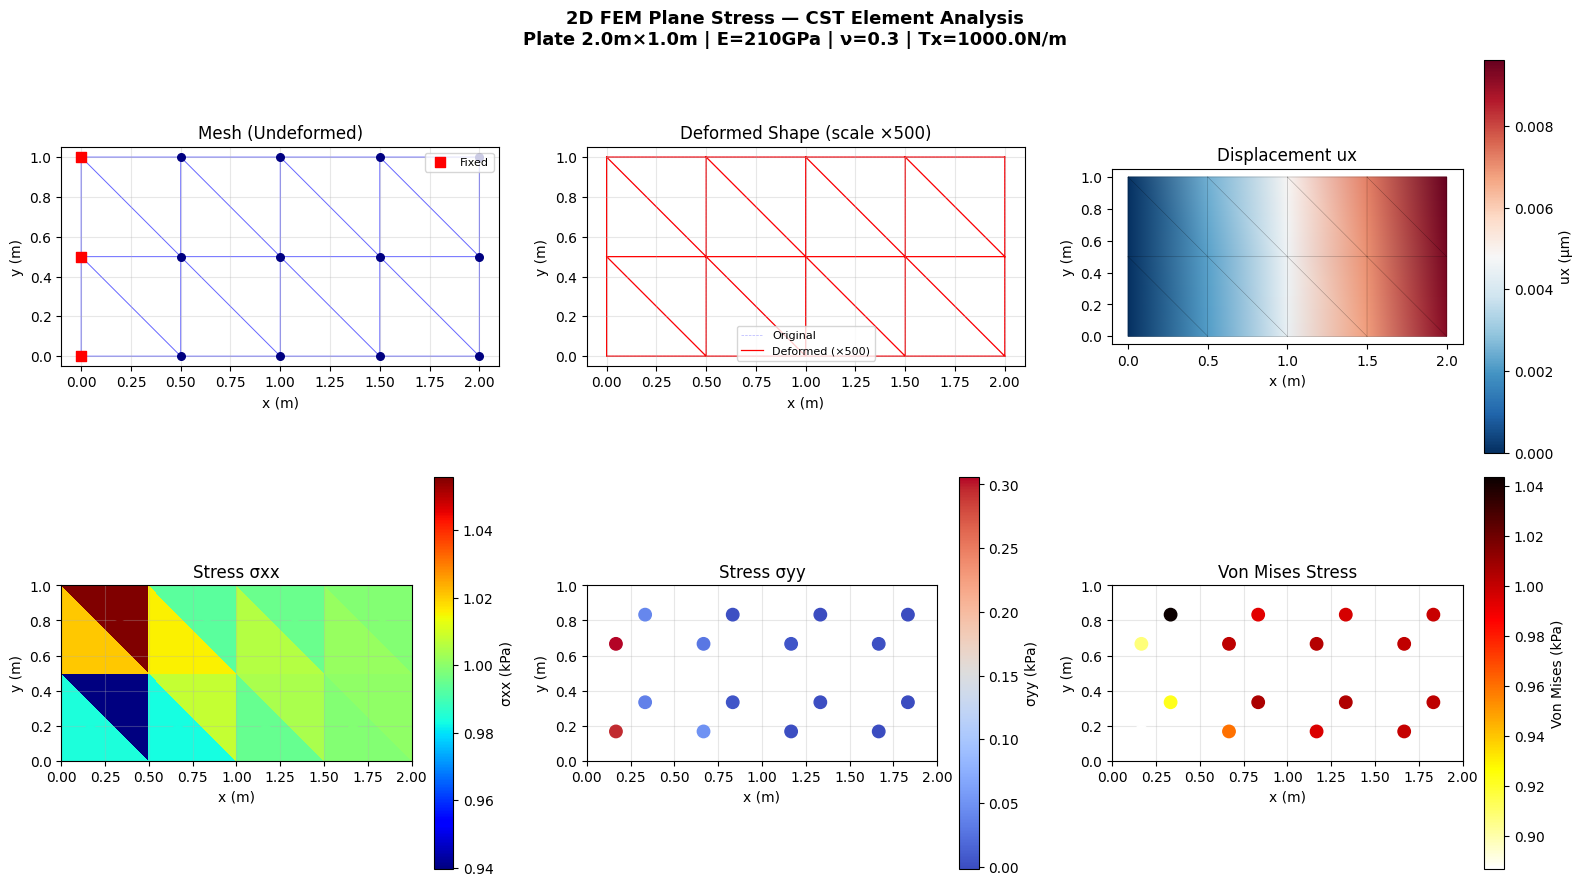

In [11]:
# VISUALIZATION
# ================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("2D FEM Plane Stress — CST Element Analysis\n"
             f"Plate {Lx}m×{Ly}m | E={E/1e9:.0f}GPa | ν={nu} | Tx={Tx}N/m",
             fontsize=13, fontweight='bold')

# Deformation scale factor for visibility
scale = 500 if ux.max() > 0 else 1
x_def = node_coords[:, 0] + scale * ux
y_def = node_coords[:, 1] + scale * uy

triang  = mtri.Triangulation(node_coords[:, 0], node_coords[:, 1], elements)
triang_d = mtri.Triangulation(x_def, y_def, elements)

# -- Undeformed mesh --
ax = axes[0, 0]
ax.triplot(triang, 'b-', linewidth=0.7, alpha=0.6)
ax.scatter(node_coords[:, 0], node_coords[:, 1], s=30, c='navy', zorder=3)
ax.scatter(node_coords[fixed_nodes, 0], node_coords[fixed_nodes, 1],
           s=60, c='red', marker='s', zorder=4, label='Fixed')
ax.set_title("Mesh (Undeformed)")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.set_aspect('equal'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# -- Deformed mesh --
ax = axes[0, 1]
ax.triplot(triang, 'b--', linewidth=0.5, alpha=0.3, label='Original')
ax.triplot(triang_d, 'r-', linewidth=0.9, label=f'Deformed (×{scale})')
ax.set_title(f"Deformed Shape (scale ×{scale})")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.set_aspect('equal'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# -- ux displacement --
ax = axes[0, 2]
tcf = ax.tripcolor(triang, ux * 1e6, shading='gouraud', cmap='RdBu_r')
ax.triplot(triang, 'k-', linewidth=0.3, alpha=0.4)
plt.colorbar(tcf, ax=ax, label='ux (µm)')
ax.set_title("Displacement ux")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.set_aspect('equal')

# -- σxx stress --
ax = axes[1, 0]
tcf2 = ax.tripcolor(triang, sigma_xx[np.repeat(np.arange(n_elements), 3).reshape(n_elements, 3)[:, 0]],
                    shading='flat', cmap='jet')
# Simpler: scatter plot of element centroids
sc = ax.scatter(elem_cx, elem_cy, c=sigma_xx / 1e3, cmap='jet', s=80, zorder=3)
plt.colorbar(sc, ax=ax, label='σxx (kPa)')
ax.set_xlim(0, Lx); ax.set_ylim(0, Ly)
ax.set_title("Stress σxx")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.set_aspect('equal'); ax.grid(alpha=0.3)

# -- σyy stress --
ax = axes[1, 1]
sc2 = ax.scatter(elem_cx, elem_cy, c=sigma_yy / 1e3, cmap='coolwarm', s=80, zorder=3)
plt.colorbar(sc2, ax=ax, label='σyy (kPa)')
ax.set_xlim(0, Lx); ax.set_ylim(0, Ly)
ax.set_title("Stress σyy")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.set_aspect('equal'); ax.grid(alpha=0.3)

# -- Von Mises --
ax = axes[1, 2]
sc3 = ax.scatter(elem_cx, elem_cy, c=vm_stress / 1e3, cmap='hot_r', s=80, zorder=3)
plt.colorbar(sc3, ax=ax, label='Von Mises (kPa)')
ax.set_xlim(0, Lx); ax.set_ylim(0, Ly)
ax.set_title("Von Mises Stress")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.set_aspect('equal'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()